# Autoencoders and variational autoencoders on digits
We implement the reconstruction and ELBO objectives directly in PyTorch. Labels are used only for visualization, never for training.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader,TensorDataset
from sklearn.model_selection import train_test_split

torch.manual_seed(26520); np.random.seed(26520)
frame=pd.read_csv('SklearnDigits.csv'); X=frame.drop(columns='target').to_numpy(np.float32)/16; y=frame.target.to_numpy()
X_train,X_test=train_test_split(X,test_size=.25,random_state=26520,stratify=y)
train_loader=DataLoader(TensorDataset(torch.tensor(X_train)),batch_size=128,shuffle=True)
test=torch.tensor(X_test)
X_train.shape,X_test.shape

((1347, 64), (450, 64))

## Deterministic autoencoder
The model, optimization loop, and held-out reconstruction calculation are explicit rather than hidden in a high-level estimator.

In [2]:
class Autoencoder(nn.Module):
    def __init__(self,latent=8):
        super().__init__(); self.encoder=nn.Sequential(nn.Linear(64,32),nn.ReLU(),nn.Linear(32,latent))
        self.decoder=nn.Sequential(nn.Linear(latent,32),nn.ReLU(),nn.Linear(32,64),nn.Sigmoid())
    def forward(self,x): return self.decoder(self.encoder(x))

ae=Autoencoder(8); optimizer=torch.optim.Adam(ae.parameters(),lr=3e-3)
for epoch in range(25):
    for (batch,) in train_loader:
        loss=((ae(batch)-batch)**2).mean(); optimizer.zero_grad(); loss.backward(); optimizer.step()
with torch.no_grad(): ae_test_mse=((ae(test)-test)**2).mean().item()
ae_test_mse

0.030337529256939888

## Variational autoencoder
The encoder outputs a mean and log variance. Reparameterization samples the code, and the loss combines Bernoulli negative log likelihood with Gaussian KL.

In [3]:
class VAE(nn.Module):
    def __init__(self,latent=8):
        super().__init__(); self.body=nn.Sequential(nn.Linear(64,32),nn.ReLU())
        self.mean=nn.Linear(32,latent); self.logvar=nn.Linear(32,latent)
        self.decoder=nn.Sequential(nn.Linear(latent,32),nn.ReLU(),nn.Linear(32,64))
    def encode(self,x):
        h=self.body(x); return self.mean(h),self.logvar(h)
    def reparameterize(self,mean,logvar):
        return mean+torch.exp(.5*logvar)*torch.randn_like(mean)
    def forward(self,x):
        mean,logvar=self.encode(x); z=self.reparameterize(mean,logvar); return self.decoder(z),mean,logvar

def vae_loss(logits,x,mean,logvar):
    reconstruction=nn.functional.binary_cross_entropy_with_logits(logits,x,reduction='sum')
    kl=-.5*torch.sum(1+logvar-mean.square()-logvar.exp())
    return (reconstruction+kl)/len(x),reconstruction/len(x),kl/len(x)

vae=VAE(8); optimizer=torch.optim.Adam(vae.parameters(),lr=2e-3)
history=[]
for epoch in range(30):
    for (batch,) in train_loader:
        logits,mean,logvar=vae(batch); loss,recon,kl=vae_loss(logits,batch,mean,logvar)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
    history.append((loss.item(),recon.item(),kl.item()))
history[-1]

(25.928749084472656, 24.039438247680664, 1.8893107175827026)

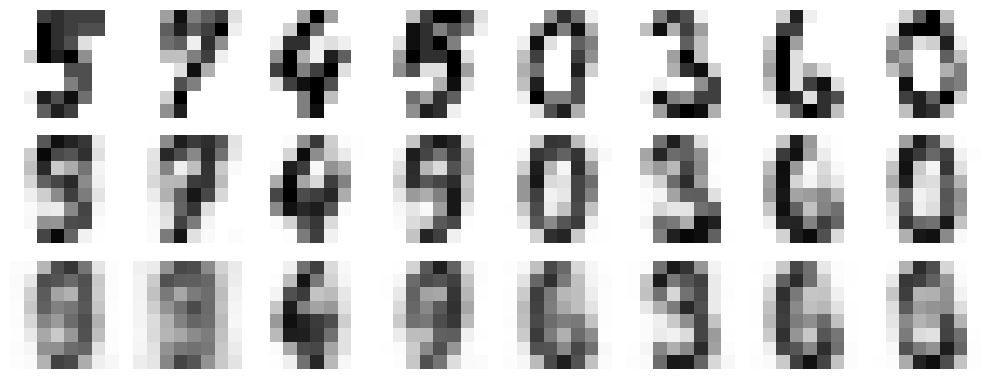

In [4]:
vae.eval()
with torch.no_grad():
    ae_rec=ae(test[:8]).numpy().reshape(-1,8,8)
    logits,mean,logvar=vae(test[:8]); vae_rec=torch.sigmoid(logits).numpy().reshape(-1,8,8)
fig,axes=plt.subplots(3,8,figsize=(10,4))
for j in range(8):
    for ax,image in zip(axes[:,j],[test[j].numpy().reshape(8,8),ae_rec[j],vae_rec[j]]): ax.imshow(image,cmap='gray_r',vmin=0,vmax=1); ax.axis('off')
axes[0,0].set_ylabel('input'); axes[1,0].set_ylabel('AE'); axes[2,0].set_ylabel('VAE'); plt.tight_layout()

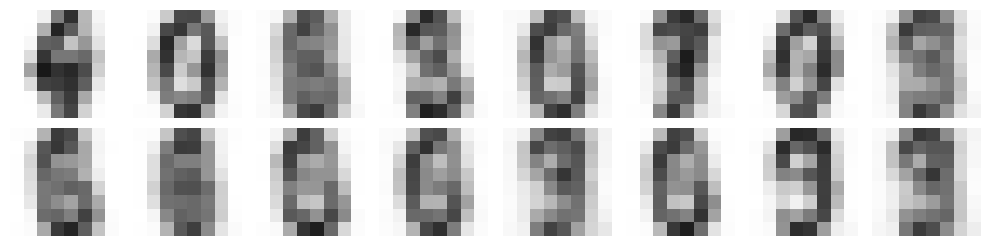

In [5]:
with torch.no_grad():
    samples=torch.sigmoid(vae.decoder(torch.randn(16,8))).numpy().reshape(-1,8,8)
fig,axes=plt.subplots(2,8,figsize=(10,2.6))
for ax,image in zip(axes.ravel(),samples): ax.imshow(image,cmap='gray_r',vmin=0,vmax=1); ax.axis('off')
plt.tight_layout()